# MÓDULO 4 — Fundamentos Estadísticos para el Análisis Predictivo
**Diagnóstico y Predictibilidad | 92-0030 | ULACIT**
**Prof. Robin Sequeira**

---
### INSTRUCCIONES
Este notebook tiene dos partes.

**PARTE 1 (primeros 40 min — hacemos juntos):**
El profesor muestra los conceptos aplicados sobre el Superstore. Ejecuten cada bloque y lean los comentarios. Entienden el qué y el por qué.

**PARTE 2 (45 min en salas de Teams):**
Aplican exactamente los mismos bloques sobre su propio dataset de proyecto. Adaptan el código a sus columnas. Interpretan sus propios resultados.

Al regresar: presentación de 5 minutos por grupo. Este notebook va al Portafolio I (Semana 8).

## PARTE 2 — ACTIVIDAD EN SALAS DE TEAMS
**Tiempo:** 45 minutos de trabajo + 15 minutos de presentaciones

### INSTRUCCIONES PARA EL GRUPO
Cada grupo aplica el análisis estadístico sobre su propio dataset de proyecto. El que definieron la semana pasada.

Carguen su dataset. Adapten cada bloque a sus columnas. No tienen que copiar el código exacto: ajústenlo a sus datos. Al final preparan 3 a 5 diapositivas (o usan el notebook) para responder las 5 preguntas de la presentación. La presentación no es reportar números. Es interpretar, razonar y conectar con su problema de negocio.

### BLOQUE A — Cargar su dataset
Reemplacen esto con la carga de su propio dataset.

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [0]:
# Si lo tienen en Databricks:
#   mi_df = spark.table("workspace.default.SU_TABLA").toPandas()
# Si lo tienen como CSV:
#   mi_df = pd.read_csv("/ruta/a/su/archivo.csv")

# Ejemplo genérico — cambien por su dataset real:
mi_df = spark.table("workspace.diagnosticopredictibilidad.trainecomerce").toPandas()

print(f"Dataset: {mi_df.shape[0]:,} filas, {mi_df.shape[1]} columnas")
print("\nColumnas:")
print(mi_df.columns.tolist())
print("\nPrimeras filas:")
mi_df.head()

Dataset: 1,460 filas, 81 columnas

Columnas:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3S

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,250000


In [0]:
df_clean = mi_df.copy()
print("Copia lista. Shape:", df_clean.shape)


##Código 3 — Diagnóstico de nulos**

nulos = df_clean.isna().mean().sort_values(ascending=False) * 100
print("Columnas con valores nulos:")
print(nulos[nulos > 0].round(2))
print("--- nulos --")
#duplicados
n_duplicados = df_clean.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

df_clean = df_clean.drop_duplicates()

cardinalidad = df_clean.nunique().sort_values(ascending=False)
print("Valores únicos por columna:")
print(cardinalidad)



#Código 8 — Imputar columna numérica con mediana**

df_demo = df_clean.copy()

mediana_sales = df_demo["SalePrice"].median()
df_demo["SalePrice"] = df_demo["SalePrice"].fillna(mediana_sales)
print(f"Valor imputado: {mediana_sales:.2f}")

mediana_LotArea = df_demo["LotArea"].median()
df_demo["LotArea"] = df_demo["LotArea"].fillna(mediana_LotArea)
print(f"Valor imputado: {mediana_LotArea:.2f}")

mediana_GrLivArea = df_demo["GrLivArea"].median()
df_demo["GrLivArea"] = df_demo["GrLivArea"].fillna(mediana_GrLivArea)
print(f"Valor imputado: {mediana_GrLivArea:.2f}")

mediana_TotalBsmtSF = df_demo["TotalBsmtSF"].median()
df_demo["TotalBsmtSF"] = df_demo["TotalBsmtSF"].fillna(mediana_TotalBsmtSF)
print(f"Valor imputado: {mediana_TotalBsmtSF:.2f}")

#Código 9 — Imputar columna categórica con moda**


Copia lista. Shape: (1460, 81)
Columnas con valores nulos:
Series([], dtype: float64)
--- nulos --
Filas duplicadas: 0
Valores únicos por columna:
Id            1460
LotArea       1073
GrLivArea      861
BsmtUnfSF      780
1stFlrSF       753
              ... 
LandSlope        3
Alley            3
Street           2
CentralAir       2
Utilities        2
Length: 81, dtype: int64
Valor imputado: 163000.00
Valor imputado: 9478.50
Valor imputado: 1464.00
Valor imputado: 991.50


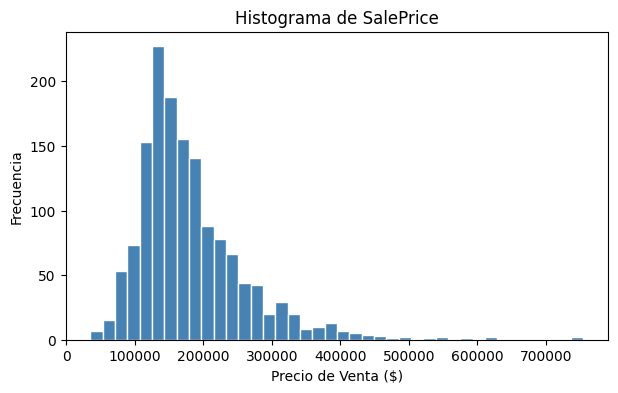

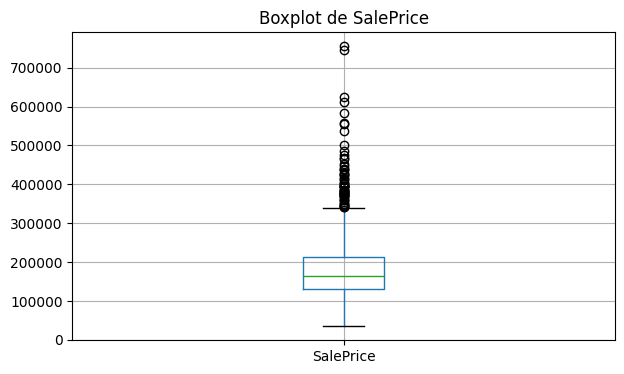

In [0]:
# 1. Gráfico 1: Histograma de la distribución
plt.figure(figsize=(7, 4))
plt.hist(df_clean['SalePrice'].dropna(), bins=40, color='steelblue', edgecolor='white') 
plt.title('Histograma de SalePrice')
plt.xlabel('Precio de Venta ($)')
plt.ylabel('Frecuencia')
plt.show()  # Muestra el histograma y cierra el lienzo para el siguiente gráfico

# 2. Gráfico 2: Boxplot para identificar Outliers (Forma correcta en Pandas)
plt.figure(figsize=(7, 4))
df_clean.boxplot(column='SalePrice')  # <- Corrección del error de atributo
plt.title('Boxplot de SalePrice')
plt.show()

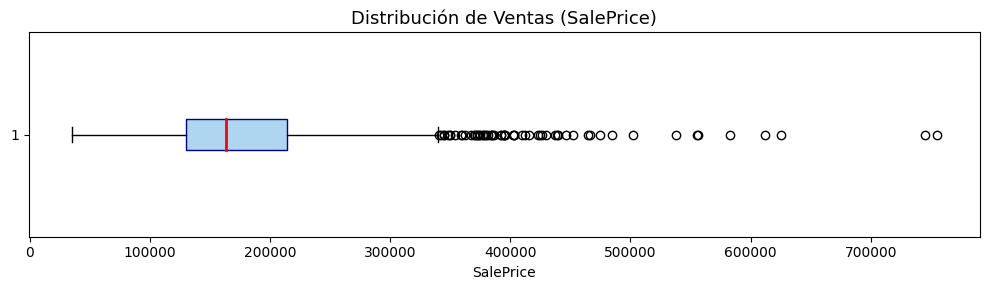

In [0]:
#Código 10 — Boxplot de ventas**

fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(df_clean["SalePrice"].dropna(), vert=False, patch_artist=True,
boxprops=dict(facecolor="#AED6F1", color="navy"),
medianprops=dict(color="red", linewidth=2))
ax.set_title("Distribución de Ventas (SalePrice)", fontsize=13)
ax.set_xlabel("SalePrice")
plt.tight_layout()
plt.show()

In [0]:
#Código 11 — Calcular límites IQR**
Q1 = df_clean["SalePrice"].quantile(0.25)
Q3 = df_clean["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")


#Código 12 — Detectar outliers**
outliers = df_clean[
(df_clean["SalePrice"] < limite_inferior) |
(df_clean["SalePrice"] > limite_superior)
]
print(f"Total de outliers: {len(outliers)}")
print(f"Porcentaje del dataset: {len(outliers)/len(df_clean)*100:.1f}%")
outliers[["YrSold", "SaleType", "SalePrice"]].head(10)

Q1: 129975.00
Q3: 214000.00
IQR: 84025.00
Limite inferior: 3937.50
Limite superior: 340037.50
Total de outliers: 61
Porcentaje del dataset: 4.2%


,YrSold,SaleType,SalePrice
11,2006,New,345000
53,2006,WD,385000
58,2006,New,438780
112,2007,New,383970
151,2008,New,372402
161,2008,WD,412500
178,2009,New,501837
185,2006,WD,475000
224,2009,WD,386250
231,2009,WD,403000


### CELDAS — Clasificar las columnas 
*(Decisión humana: qué tipo es cada columna)*
###  — Preparar X (predictoras) e y (objetivo)
###  — Crear los transformadores individuales

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Columnas que usaremos como predictoras (excluimos IDs, fechas y texto de alta cardinalidad)
columnas_excluir = [
    "Id",          
    "SalePrice", 
    
 
    "Neighborhood",  
    "Exterior1st",  
    "Exterior2nd" 
]

target = "SalePrice"

columnas_predictoras = [col for col in df_clean.columns if col not in columnas_excluir]
df_predictoras = df_clean[columnas_predictoras]


num_cols = df_predictoras.select_dtypes(include=[np.number]).columns.tolist()


cat_cols = df_predictoras.select_dtypes(include=['object', 'category']).columns.tolist()


print(f" Variable objetivo: '{target}'")
print(f"Columnas excluidas ({len(columnas_excluir)}): {columnas_excluir}")
print(f"Total de variables predictoras que se usarán: {len(columnas_predictoras)}")
print("-" * 50)


print(f" Columnas numéricas detectadas ({len(num_cols)}):")
print(num_cols[:15], "... (y más)") 

print(f"\nColumnas categóricas detectadas ({len(cat_cols)}):")
print(cat_cols[:10], "... (y más)")

X = df_clean[num_cols + cat_cols].copy()
y = df_clean[target].copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nPrimeras filas de X:")
X.head()

num_transformer = StandardScaler()

cat_transformer = OneHotEncoder(handle_unknown="ignore")

print("Transformadores creados:")
print("  Numéricas  →", num_transformer)
print("  Categóricas →", cat_transformer)


 Variable objetivo: 'SalePrice'
Columnas excluidas (5): ['Id', 'SalePrice', 'Neighborhood', 'Exterior1st', 'Exterior2nd']
Total de variables predictoras que se usarán: 76
--------------------------------------------------
 Columnas numéricas detectadas (33):
['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath'] ... (y más)

Columnas categóricas detectadas (43):
['MSZoning', 'LotFrontage', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1'] ... (y más)
Shape de X: (1460, 76)
Shape de y: (1460,)

Primeras filas de X:
Transformadores creados:
  Numéricas  → StandardScaler()
  Categóricas → OneHotEncoder(handle_unknown='ignore')


### CELDA — Construir el ColumnTransformer
*(Aplica el transformador correcto a cada grupo de columnas)*

In [0]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),   # StandardScaler a columnas numéricas
        ("cat", cat_transformer, cat_cols)    # OneHotEncoder a columnas categóricas
    ],
    remainder="drop"    # descarta cualquier otra columna
)

print("ColumnTransformer configurado correctamente.")
print("Grupos:")
print("  Numéricas:", num_cols)
print("  Categóricas:", cat_cols)


ColumnTransformer configurado correctamente.
Grupos:
  Numéricas: ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
  Categóricas: ['MSZoning', 'LotFrontage', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'Gara

### CELDA — Construir el Pipeline completo

In [0]:
pipe = Pipeline(steps=[
    ("prep", preprocessor)
])

print("Pipeline creado.")
print("Pasos:", [step[0] for step in pipe.steps])


Pipeline creado.
Pasos: ['prep']


### CELDA — CORRECTO: Dividir PRIMERO, luego ajustar el Pipeline
*(Esto evita el data leakage)*

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("División completada:")
print("  X_train:", X_train.shape)
print("  X_test:", X_test.shape)
print("  y_train:", y_train.shape)
print("  y_test:", y_test.shape)

División completada:
  X_train: (1168, 76)
  X_test: (292, 76)
  y_train: (1168,)
  y_test: (292,)


### CELDA — Ajustar y transformar con el Pipeline
*(fit SOLO con train, luego transform ambos conjuntos)*

In [0]:
# El Pipeline aprende solo con los datos de entrenamiento
X_train_t = pipe.fit_transform(X_train)

# Luego transforma el test usando lo que aprendió (sin verlo de nuevo)
X_test_t  = pipe.transform(X_test)

print("Pipeline aplicado correctamente.")
print("Shape X_train transformado:", X_train_t.shape)
print("Shape X_test transformado: ", X_test_t.shape)

# Todas las columnas son ahora numéricas
print("\nTipo de datos:", type(X_train_t))

Pipeline aplicado correctamente.
Shape X_train transformado: (1168, 733)
Shape X_test transformado:  (292, 733)

Tipo de datos: <class 'scipy.sparse._csr.csr_matrix'>


### CELDA — ¿Qué columnas generó el OneHotEncoder?

In [0]:
# Nombres de las columnas generadas
cat_feature_names = pipe.named_steps["prep"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(cat_feature_names)

print(f"Total columnas transformadas: {len(all_feature_names)}")
print("\nColumnas numéricas (sin cambio de nombre):", num_cols)
print("\nColumnas generadas por OneHotEncoder:")
for name in cat_feature_names:
    print(" ", name)

Total columnas transformadas: 733

Columnas numéricas (sin cambio de nombre): ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Columnas generadas por OneHotEncoder:
  MSZoning_C (all)
  MSZoning_FV
  MSZoning_RH
  MSZoning_RL
  MSZoning_RM
  LotFrontage_100
  LotFrontage_101
  LotFrontage_102
  LotFrontage_103
  LotFrontage_104
  LotFrontage_105
  LotFrontage_106
  LotFrontage_107
  LotFrontage_108
  LotFrontage_109
  LotFrontage_110
  LotFrontage_111
  LotFrontage_112
  LotFrontage_114
  LotFrontage_115
  LotFrontage_118
  LotFrontage_120
  LotFrontage_121
  LotFrontage_122
  LotFron

### BLOQUE B — Estadística descriptiva de su dataset

In [0]:
# Resumen general
print("=== Resumen estadístico ===")
print(mi_df.describe().round(2))

# Identifiquen sus columnas numéricas clave
# (las que son relevantes para su problema de negocio)
COLUMNA_OBJETIVO = "SalePrice"   # variable objetivo del dataset de casas

print(f"\n=== Análisis de {COLUMNA_OBJETIVO} ===")
print(f"Media:    {mi_df[COLUMNA_OBJETIVO].mean():.2f}")
print(f"Mediana:  {mi_df[COLUMNA_OBJETIVO].median():.2f}")
print(f"Std:      {mi_df[COLUMNA_OBJETIVO].std():.2f}")
print(f"Sesgo:    {mi_df[COLUMNA_OBJETIVO].skew():.2f}")

# Pregunten: ¿la media y la mediana son similares?
# Si no → hay sesgo o valores extremos → eso afecta el modelo.

=== Resumen estadístico ===
            Id  MSSubClass    LotArea  ...   MoSold   YrSold  SalePrice
count  1460.00      1460.0    1460.00  ...  1460.00  1460.00     1460.0
mean    730.50        56.9   10516.83  ...     6.32  2007.82   180921.2
std     421.61        42.3    9981.26  ...     2.70     1.33    79442.5
min       1.00        20.0    1300.00  ...     1.00  2006.00    34900.0
25%     365.75        20.0    7553.50  ...     5.00  2007.00   129975.0
50%     730.50        50.0    9478.50  ...     6.00  2008.00   163000.0
75%    1095.25        70.0   11601.50  ...     8.00  2009.00   214000.0
max    1460.00       190.0  215245.00  ...    12.00  2010.00   755000.0

[8 rows x 35 columns]

=== Análisis de SalePrice ===
Media:    180921.20
Mediana:  163000.00
Std:      79442.50
Sesgo:    1.88


### BLOQUE C — Distribución de la variable principal
Grafiquen la distribución de su variable más importante.

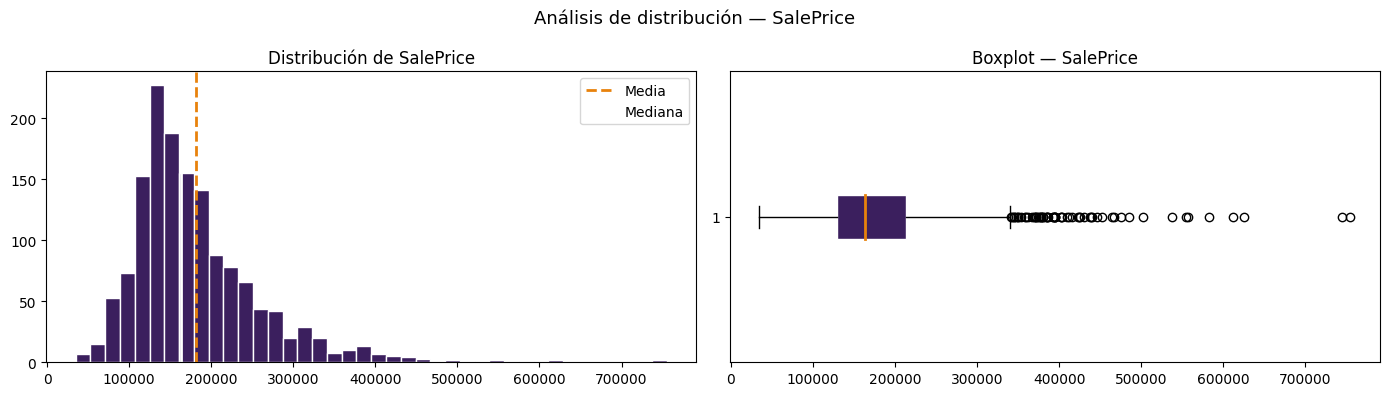

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(mi_df[COLUMNA_OBJETIVO].dropna(), bins=40, color='#3B1F5E', edgecolor='white')
axes[0].axvline(mi_df[COLUMNA_OBJETIVO].mean(),   color='#E8820C', lw=2, ls='--', label='Media')
axes[0].axvline(mi_df[COLUMNA_OBJETIVO].median(), color='white',   lw=2, ls='-',  label='Mediana')
axes[0].set_title(f'Distribución de {COLUMNA_OBJETIVO}')
axes[0].legend()

# Boxplot para visualizar outliers
axes[1].boxplot(mi_df[COLUMNA_OBJETIVO].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3B1F5E', color='white'),
                medianprops=dict(color='#E8820C', linewidth=2))
axes[1].set_title(f'Boxplot — {COLUMNA_OBJETIVO}')

plt.suptitle(f'Análisis de distribución — {COLUMNA_OBJETIVO}', fontsize=13)
plt.tight_layout()
plt.show()

# ¿La distribución se parece a una campana?
# ¿O tiene cola larga? ¿De qué lado?
# Documenten la respuesta en una celda Markdown.

### BLOQUE D — Correlaciones en su dataset
¿Qué variables numéricas están relacionadas entre sí? ¿Cuál tiene mayor relación con su variable objetivo?

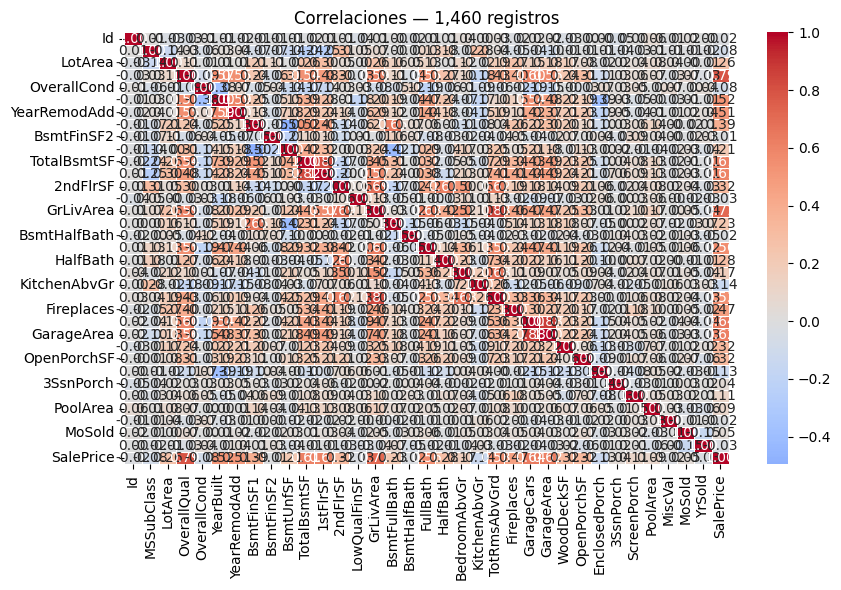


Correlación con SalePrice:
OverallQual      0.791
GrLivArea        0.709
GarageCars       0.640
GarageArea       0.623
TotalBsmtSF      0.614
1stFlrSF         0.606
FullBath         0.561
TotRmsAbvGrd     0.534
YearBuilt        0.523
YearRemodAdd     0.507
Fireplaces       0.467
BsmtFinSF1       0.386
WoodDeckSF       0.324
2ndFlrSF         0.319
OpenPorchSF      0.316
HalfBath         0.284
LotArea          0.264
BsmtFullBath     0.227
BsmtUnfSF        0.214
BedroomAbvGr     0.168
KitchenAbvGr    -0.136
EnclosedPorch   -0.129
ScreenPorch      0.111
PoolArea         0.092
MSSubClass      -0.084
OverallCond     -0.078
MoSold           0.046
3SsnPorch        0.045
YrSold          -0.029
LowQualFinSF    -0.026
Id              -0.022
MiscVal         -0.021
BsmtHalfBath    -0.017
BsmtFinSF2      -0.011
Name: SalePrice, dtype: float64


In [0]:
numericas = mi_df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f'Correlaciones — {mi_df.shape[0]:,} registros')
plt.tight_layout()
plt.show()

# Tabla de correlación con la variable objetivo
print(f"\nCorrelación con {COLUMNA_OBJETIVO}:")
corr_obj = numericas.corr()[COLUMNA_OBJETIVO].drop(COLUMNA_OBJETIVO)
print(corr_obj.sort_values(key=abs, ascending=False).round(3))

# ¿Hay alguna variable con r > 0.5 o r < -0.5?
# ¿Hay alguna relación que NO esperaban?
# ¿Qué variable tiene más potencial como predictora?

In [0]:
corr_con_sales = df_clean[num_cols + [target]].corr()[target].drop(target)
corr_ordenada  = corr_con_sales.abs().sort_values(ascending=False)

print("Correlación absoluta de las numéricas con Sales:\n")
for col, val in corr_ordenada.items():
    estado = "✓ INCLUIR" if val > 0.2 else "✗ descartable"
    print(f"  {col:20s}: {corr_con_sales[col]:+.3f}  ({val:.3f})  {estado}")

print("\nUmbral aplicado: correlación absoluta > 0.2")

Correlación absoluta de las numéricas con Sales:

  OverallQual         : +0.791  (0.791)  ✓ INCLUIR
  GrLivArea           : +0.709  (0.709)  ✓ INCLUIR
  GarageCars          : +0.640  (0.640)  ✓ INCLUIR
  GarageArea          : +0.623  (0.623)  ✓ INCLUIR
  TotalBsmtSF         : +0.614  (0.614)  ✓ INCLUIR
  1stFlrSF            : +0.606  (0.606)  ✓ INCLUIR
  FullBath            : +0.561  (0.561)  ✓ INCLUIR
  TotRmsAbvGrd        : +0.534  (0.534)  ✓ INCLUIR
  YearBuilt           : +0.523  (0.523)  ✓ INCLUIR
  YearRemodAdd        : +0.507  (0.507)  ✓ INCLUIR
  Fireplaces          : +0.467  (0.467)  ✓ INCLUIR
  BsmtFinSF1          : +0.386  (0.386)  ✓ INCLUIR
  WoodDeckSF          : +0.324  (0.324)  ✓ INCLUIR
  2ndFlrSF            : +0.319  (0.319)  ✓ INCLUIR
  OpenPorchSF         : +0.316  (0.316)  ✓ INCLUIR
  HalfBath            : +0.284  (0.284)  ✓ INCLUIR
  LotArea             : +0.264  (0.264)  ✓ INCLUIR
  BsmtFullBath        : +0.227  (0.227)  ✓ INCLUIR
  BsmtUnfSF           : +0.214  

In [0]:
# Variable numérica con mayor correlación absoluta con la variable objetivo
max_corr_col = corr_con_sales.abs().idxmax()
max_corr_val = corr_con_sales[max_corr_col]

print(f"La variable numérica con mayor correlación (valor absoluto) con '{target}' es:")
print(f"  {max_corr_col}: {max_corr_val:+.3f}")


La variable numérica con mayor correlación (valor absoluto) con 'SalePrice' es:
  OverallQual: +0.791


### CELDA  — Selección de características: correlación con SalePrice

In [0]:
# Calculamos correlación de Pearson de las variables numéricas con SalePrice
# (antes de transformar, sobre el dataset original para legibilidad)

corr_con_sales = df_clean[num_cols + [target]].corr()[target].drop(target)
corr_ordenada  = corr_con_sales.abs().sort_values(ascending=False)

print("Correlación absoluta de las numéricas con Sales:\n")
for col, val in corr_ordenada.items():
    estado = "✓ INCLUIR" if val > 0.2 else "✗ descartable"
    print(f"  {col:20s}: {corr_con_sales[col]:+.3f}  ({val:.3f})  {estado}")

print("\nUmbral aplicado: correlación absoluta > 0.2")

Correlación absoluta de las numéricas con Sales:

  OverallQual         : +0.791  (0.791)  ✓ INCLUIR
  GrLivArea           : +0.709  (0.709)  ✓ INCLUIR
  GarageCars          : +0.640  (0.640)  ✓ INCLUIR
  GarageArea          : +0.623  (0.623)  ✓ INCLUIR
  TotalBsmtSF         : +0.614  (0.614)  ✓ INCLUIR
  1stFlrSF            : +0.606  (0.606)  ✓ INCLUIR
  FullBath            : +0.561  (0.561)  ✓ INCLUIR
  TotRmsAbvGrd        : +0.534  (0.534)  ✓ INCLUIR
  YearBuilt           : +0.523  (0.523)  ✓ INCLUIR
  YearRemodAdd        : +0.507  (0.507)  ✓ INCLUIR
  Fireplaces          : +0.467  (0.467)  ✓ INCLUIR
  BsmtFinSF1          : +0.386  (0.386)  ✓ INCLUIR
  WoodDeckSF          : +0.324  (0.324)  ✓ INCLUIR
  2ndFlrSF            : +0.319  (0.319)  ✓ INCLUIR
  OpenPorchSF         : +0.316  (0.316)  ✓ INCLUIR
  HalfBath            : +0.284  (0.284)  ✓ INCLUIR
  LotArea             : +0.264  (0.264)  ✓ INCLUIR
  BsmtFullBath        : +0.227  (0.227)  ✓ INCLUIR
  BsmtUnfSF           : +0.214  

In [0]:
# Identificar pares de variables con alta correlación entre sí (multicolinealidad)
# Umbral típico: |correlación| > 0.8 indica multicolinealidad problemática

UMBRAL_MULTI = 0.8

# Matriz de correlación solo entre predictoras numéricas (excluimos SalePrice)
corr_matrix = df_clean[num_cols].corr()

# Encontrar pares con correlación alta
print("=== MULTICOLINEALIDAD DETECTADA ===")
print(f"Pares con |correlación| > {UMBRAL_MULTI}:\n")

pares_problematicos = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > UMBRAL_MULTI:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            pares_problematicos.append((var1, var2, corr_val))
            print(f"  {var1:20s} ↔ {var2:20s}  r = {corr_val:+.3f}")

if len(pares_problematicos) == 0:
    print("  ✓ No se detectaron pares con correlación muy alta")
else:
    print(f"\n⚠️  {len(pares_problematicos)} par(es) problemático(s) detectado(s)")

=== MULTICOLINEALIDAD DETECTADA ===
Pares con |correlación| > 0.8:

  TotalBsmtSF          ↔ 1stFlrSF              r = +0.820
  GrLivArea            ↔ TotRmsAbvGrd          r = +0.825
  GarageCars           ↔ GarageArea            r = +0.882

⚠️  3 par(es) problemático(s) detectado(s)


In [0]:
# Analizar cada par problemático en detalle
print("\n=== ANÁLISIS DETALLADO DE MULTICOLINEALIDAD ===\n")

for var1, var2, corr_val in pares_problematicos:
    print(f"\n📊 PAR: {var1} ↔ {var2} (r = {corr_val:+.3f})")
    print("─" * 50)
    
    # Correlación individual con SalePrice
    corr_var1 = corr_con_sales[var1]
    corr_var2 = corr_con_sales[var2]
    
    print(f"  {var1:20s} → SalePrice: {corr_var1:+.3f}")
    print(f"  {var2:20s} → SalePrice: {corr_var2:+.3f}")
    
    # Sugerencia
    if abs(corr_var1) > abs(corr_var2):
        print(f"\n  💡 Sugerencia: Mantener {var1}, considerar eliminar {var2}")
    elif abs(corr_var2) > abs(corr_var1):
        print(f"\n  💡 Sugerencia: Mantener {var2}, considerar eliminar {var1}")
    else:
        print(f"\n  💡 Sugerencia: Ambas tienen poder predictivo similar")
        print(f"     → Elegir la más interpretable para el negocio")


=== ANÁLISIS DETALLADO DE MULTICOLINEALIDAD ===


📊 PAR: TotalBsmtSF ↔ 1stFlrSF (r = +0.820)
──────────────────────────────────────────────────
  TotalBsmtSF          → SalePrice: +0.614
  1stFlrSF             → SalePrice: +0.606

  💡 Sugerencia: Mantener TotalBsmtSF, considerar eliminar 1stFlrSF

📊 PAR: GrLivArea ↔ TotRmsAbvGrd (r = +0.825)
──────────────────────────────────────────────────
  GrLivArea            → SalePrice: +0.709
  TotRmsAbvGrd         → SalePrice: +0.534

  💡 Sugerencia: Mantener GrLivArea, considerar eliminar TotRmsAbvGrd

📊 PAR: GarageCars ↔ GarageArea (r = +0.882)
──────────────────────────────────────────────────
  GarageCars           → SalePrice: +0.640
  GarageArea           → SalePrice: +0.623

  💡 Sugerencia: Mantener GarageCars, considerar eliminar GarageArea


In [0]:
# Calcular correlación de Spearman (basada en rangos, robusta a outliers y relaciones monotónicas no lineales)
from scipy.stats import spearmanr

# Correlación de Spearman con SalePrice
spearman_correlations = {}
for col in num_cols:
    # Eliminar NaN para el cálculo
    valid_mask = df_clean[col].notna() & df_clean[target].notna()
    if valid_mask.sum() > 0:
        corr, _ = spearmanr(df_clean.loc[valid_mask, col], df_clean.loc[valid_mask, target])
        spearman_correlations[col] = corr

spearman_series = pd.Series(spearman_correlations)

# Comparar Pearson vs Spearman
print("=== COMPARACIÓN PEARSON vs SPEARMAN ===")
print("\nTop 10 variables por correlación absoluta:\n")
print(f"{'Variable':20s} {'Pearson':>8s} {'Spearman':>8s} {'Diferencia':>12s} {'Interpretación':>20s}")
print("─" * 75)

for col in corr_ordenada.head(15).index:
    pearson_val = corr_con_sales[col]
    spearman_val = spearman_series[col]
    diff = abs(pearson_val - spearman_val)
    
    # Interpretación de la diferencia
    if diff > 0.15:
        interpretacion = "⚠️ OUTLIERS/NO LINEAL"
    elif diff > 0.08:
        interpretacion = "⚡ Revisar"
    else:
        interpretacion = "✓ Similar"
    
    print(f"{col:20s} {pearson_val:+8.3f} {spearman_val:+8.3f} {diff:12.3f} {interpretacion:>20s}")

print("\n💡 Interpretación:")
print("  • Diferencia < 0.08: Relación lineal, pocas outliers")
print("  • Diferencia > 0.15: Outliers fuertes o relación no lineal (monotónica pero no recta)")
print("  • Spearman > Pearson: Outliers 'achatan' la correlación lineal")
print("  • Pearson > Spearman: Relación fuerte en extremos, débil en el medio")

=== COMPARACIÓN PEARSON vs SPEARMAN ===

Top 10 variables por correlación absoluta:

Variable              Pearson Spearman   Diferencia       Interpretación
───────────────────────────────────────────────────────────────────────────
OverallQual            +0.791   +0.810        0.019            ✓ Similar
GrLivArea              +0.709   +0.731        0.023            ✓ Similar
GarageCars             +0.640   +0.691        0.050            ✓ Similar
GarageArea             +0.623   +0.649        0.026            ✓ Similar
TotalBsmtSF            +0.614   +0.603        0.011            ✓ Similar
1stFlrSF               +0.606   +0.575        0.030            ✓ Similar
FullBath               +0.561   +0.636        0.075            ✓ Similar
TotRmsAbvGrd           +0.534   +0.533        0.001            ✓ Similar
YearBuilt              +0.523   +0.653        0.130            ⚡ Revisar
YearRemodAdd           +0.507   +0.571        0.064            ✓ Similar
Fireplaces             +0.467   +0.5


=== VARIABLES CON MAYOR DIFERENCIA PEARSON-SPEARMAN ===

🔍 LotArea:
   Pearson:  +0.264
   Spearman: +0.456
   Diferencia: 0.193

🔍 OpenPorchSF:
   Pearson:  +0.316
   Spearman: +0.478
   Diferencia: 0.162

🔍 YearBuilt:
   Pearson:  +0.523
   Spearman: +0.653
   Diferencia: 0.130


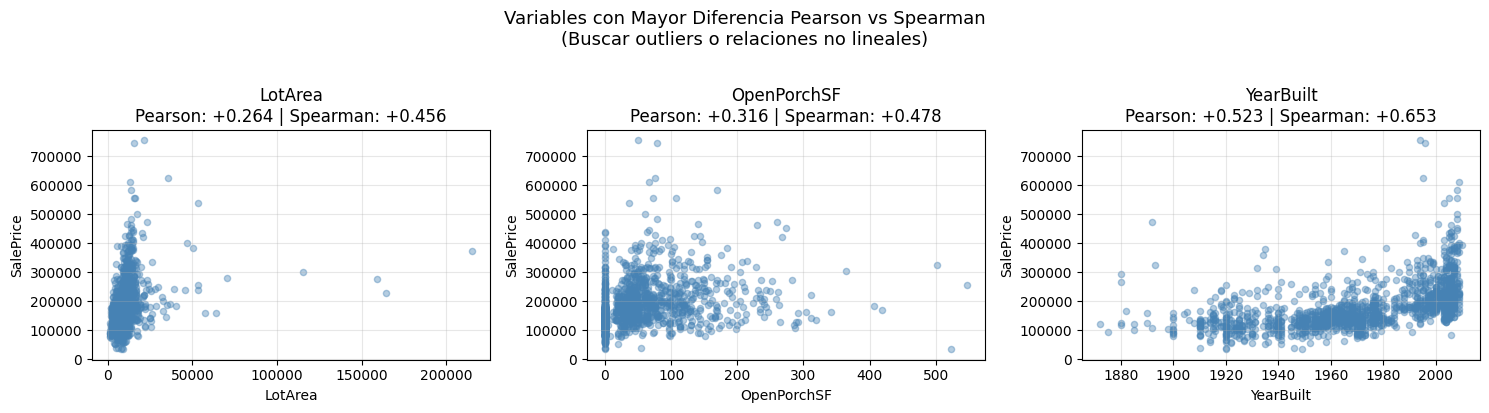


📊 Qué buscar en los gráficos:
  • Outliers extremos (puntos aislados lejos del patrón)
  • Relaciones curvas (no rectas)
  • Cambios de pendiente (comportamiento diferente en rangos bajos vs altos)


In [0]:
# Identificar las 3 variables con mayor diferencia Pearson-Spearman
diff_series = abs(pd.Series(corr_con_sales) - spearman_series)
top_diff = diff_series.nlargest(3)

print("\n=== VARIABLES CON MAYOR DIFERENCIA PEARSON-SPEARMAN ===")
for col in top_diff.index:
    print(f"\n🔍 {col}:")
    print(f"   Pearson:  {corr_con_sales[col]:+.3f}")
    print(f"   Spearman: {spearman_series[col]:+.3f}")
    print(f"   Diferencia: {diff_series[col]:.3f}")

# Visualizar la relación para entender POR QUÉ difieren
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(top_diff.index):
    ax = axes[idx]
    
    # Scatter plot para ver la relación
    valid_mask = df_clean[col].notna() & df_clean[target].notna()
    x = df_clean.loc[valid_mask, col]
    y = df_clean.loc[valid_mask, target]
    
    ax.scatter(x, y, alpha=0.4, s=20, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{col}\nPearson: {corr_con_sales[col]:+.3f} | Spearman: {spearman_series[col]:+.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Variables con Mayor Diferencia Pearson vs Spearman\n(Buscar outliers o relaciones no lineales)', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Qué buscar en los gráficos:")
print("  • Outliers extremos (puntos aislados lejos del patrón)")
print("  • Relaciones curvas (no rectas)")
print("  • Cambios de pendiente (comportamiento diferente en rangos bajos vs altos)")

### CELDA — Filtrar columnas por umbral de correlación

In [0]:
UMBRAL = 0.2

# Columnas que superan el umbral
cols_seleccionadas = corr_con_sales[corr_con_sales.abs() > UMBRAL].index.tolist()
cols_descartadas   = corr_con_sales[corr_con_sales.abs() <= UMBRAL].index.tolist()

print(f"Columnas que pasan el filtro (|correlación| > {UMBRAL}):")
for col in cols_seleccionadas:
    print(f"  {col}: {corr_con_sales[col]:+.3f}")

print(f"\nColumnas descartables (|correlación| <= {UMBRAL}):")
for col in cols_descartadas:
    print(f"  {col}: {corr_con_sales[col]:+.3f}")

Columnas que pasan el filtro (|correlación| > 0.2):
  LotArea: +0.264
  OverallQual: +0.791
  YearBuilt: +0.523
  YearRemodAdd: +0.507
  BsmtFinSF1: +0.386
  BsmtUnfSF: +0.214
  TotalBsmtSF: +0.614
  1stFlrSF: +0.606
  2ndFlrSF: +0.319
  GrLivArea: +0.709
  BsmtFullBath: +0.227
  FullBath: +0.561
  HalfBath: +0.284
  TotRmsAbvGrd: +0.534
  Fireplaces: +0.467
  GarageCars: +0.640
  GarageArea: +0.623
  WoodDeckSF: +0.324
  OpenPorchSF: +0.316

Columnas descartables (|correlación| <= 0.2):
  MSSubClass: -0.084
  OverallCond: -0.078
  BsmtFinSF2: -0.011
  LowQualFinSF: -0.026
  BsmtHalfBath: -0.017
  BedroomAbvGr: +0.168
  KitchenAbvGr: -0.136
  EnclosedPorch: -0.129
  3SsnPorch: +0.045
  ScreenPorch: +0.111
  PoolArea: +0.092
  MiscVal: -0.021
  MoSold: +0.046
  YrSold: -0.029


### CELDA — Pipeline con solo las columnas seleccionadas
*(Reentrenamos con las columnas que pasaron el filtro de correlación)*

In [0]:
# Actualizamos las listas
num_cols_sel = [col for col in cols_seleccionadas]
# (las categóricas se mantienen; el filtro de correlación se aplica a numéricas)

print("Columnas numéricas seleccionadas:", num_cols_sel)
print("Columnas categóricas (sin cambio):", cat_cols)

# Pipeline con columnas filtradas
preprocessor_sel = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_sel),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

pipe_sel = Pipeline(steps=[("prep", preprocessor_sel)])

X_sel = df_clean[num_cols_sel + cat_cols].copy()

X_train_s, X_test_s, _, _ = train_test_split(X_sel, y, test_size=0.2, random_state=42)

X_train_final = pipe_sel.fit_transform(X_train_s)
X_test_final  = pipe_sel.transform(X_test_s)

print("\nShape final (columnas seleccionadas):", X_train_final.shape)
print("Listo para entrenar el modelo en módulos siguientes.")


Columnas numéricas seleccionadas: ['LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']
Columnas categóricas (sin cambio): ['MSZoning', 'LotFrontage', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Shape final (columnas seleccionadas): (1168, 719)
Listo para entrenar el modelo en módulos

### CELDA — Resumen del Procesamiento


In [0]:
print("=" * 55)
print("  RESUMEN DEL PREPROCESAMIENTO")
print("=" * 55)
print()
print(f"Dataset original:         {df_clean.shape}")
print(f"Columnas numéricas usadas:  {num_cols}")
print(f"Columnas categóricas usadas: {cat_cols}")
print()
print(f"Después del Pipeline completo:")
print(f"  X_train transformado:   {X_train_t.shape}")
print(f"  X_test transformado:    {X_test_t.shape}")
print()
print(f"Después de selección por correlación (>{UMBRAL}):")
print(f"  X_train final:          {X_train_final.shape}")
print(f"  X_test final:           {X_test_final.shape}")
print()
print("=" * 55)

  RESUMEN DEL PREPROCESAMIENTO

Dataset original:         (1460, 81)
Columnas numéricas usadas:  ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Columnas categóricas usadas: ['MSZoning', 'LotFrontage', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fir

### BLOQUE E — Análisis por segmento (si aplica)
Si su dataset tiene una columna categórica relevante (tipo de cliente, categoría de producto, región, etc.) úsenla para ver si el comportamiento cambia entre grupos.

=== SalePrice por Foundation ===
                 mean    median       std  count
Foundation                                      
BrkTil      132291.08  125250.0  54592.39    146
CBlock      149805.71  141500.0  48295.04    634
PConc       225230.44  205000.0  86865.98    647
Slab        107365.62  104150.0  34213.98     24
Stone       165959.17  126500.0  78557.70      6
Wood        185666.67  164000.0  56695.09      3


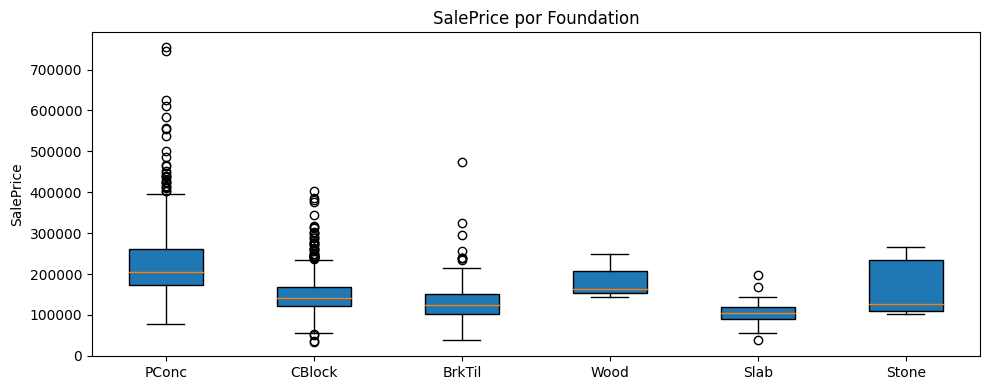

In [0]:
COLUMNA_SEGMENTO = "Foundation"   # cambia esto

print(f"=== {COLUMNA_OBJETIVO} por {COLUMNA_SEGMENTO} ===")
print(mi_df.groupby(COLUMNA_SEGMENTO)[COLUMNA_OBJETIVO]
      .agg(['mean', 'median', 'std', 'count'])
      .round(2))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 4))
grupos = [mi_df[mi_df[COLUMNA_SEGMENTO] == g][COLUMNA_OBJETIVO].dropna()
          for g in mi_df[COLUMNA_SEGMENTO].unique()]
etiquetas = mi_df[COLUMNA_SEGMENTO].unique().tolist()
ax.boxplot(grupos, labels=etiquetas, patch_artist=True)
ax.set_title(f'{COLUMNA_OBJETIVO} por {COLUMNA_SEGMENTO}')
ax.set_ylabel(COLUMNA_OBJETIVO)
plt.tight_layout()
plt.show()

In [0]:
# Analizar múltiples variables categóricas para encontrar diferencias prácticas en SalePrice
import numpy as np

print("=== ANÁLISIS POR SEGMENTO: SALEPRICE POR CATEGORÍA ===")
print("\nBuscando variables categóricas con diferencias prácticas significativas...\n")

# Seleccionar variables categóricas relevantes para análisis
categoricas_analizar = [
    'OverallQual',      # Calidad general (1-10)
    'Foundation',       # Tipo de fundación  
    'BldgType',         # Tipo de edificio
    'HouseStyle',       # Estilo de casa
    'CentralAir',       # Aire acondicionado central (Y/N)
    'GarageType',       # Tipo de garaje
]

# Para cada categoría, calcular estadísticas y encontrar el rango
resultados = []

for col in categoricas_analizar:
    if col not in df_clean.columns:
        continue
        
    stats_grupo = df_clean.groupby(col)['SalePrice'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('median', 'median'),
        ('std', 'std')
    ]).round(0)
    
    # Ordenar por media
    stats_grupo = stats_grupo.sort_values('mean', ascending=False)
    
    # Identificar mayor y menor
    grupo_max = stats_grupo.index[0]
    grupo_min = stats_grupo.index[-1]
    precio_max = stats_grupo.loc[grupo_max, 'mean']
    precio_min = stats_grupo.loc[grupo_min, 'mean']
    diferencia_abs = precio_max - precio_min
    diferencia_pct = (diferencia_abs / precio_min) * 100
    
    resultados.append({
        'Variable': col,
        'Grupo_Max': grupo_max,
        'Precio_Max': precio_max,
        'Grupo_Min': grupo_min,
        'Precio_Min': precio_min,
        'Diferencia_$': diferencia_abs,
        'Diferencia_%': diferencia_pct,
        'N_Grupos': len(stats_grupo)
    })
    
    print(f"\n{'='*60}")
    print(f"VARIABLE: {col} ({len(stats_grupo)} categorías)")
    print(f"{'='*60}")
    print(f"\n  📈 Mayor promedio:  {str(grupo_max):20s} → ${precio_max:>10,.0f}")
    print(f"  📉 Menor promedio:  {str(grupo_min):20s} → ${precio_min:>10,.0f}")
    print(f"\n  💥 Diferencia:      ${diferencia_abs:>10,.0f}  ({diferencia_pct:>5.1f}%)")
    
    # Interpretación práctica
    if diferencia_pct > 100:
        print(f"  ⚠️  IMPACTO MUY ALTO: El grupo superior vale más del DOBLE que el inferior")
    elif diferencia_pct > 50:
        print(f"  ⚡ IMPACTO ALTO: Diferencia superior al 50% — muy relevante para el negocio")
    elif diferencia_pct > 20:
        print(f"  🔵 IMPACTO MODERADO: Diferencia del 20-50% — relevante pero no extrema")
    else:
        print(f"  ℹ️  IMPACTO BAJO: Diferencia < 20% — puede no justificar diferenciación")
    
    print(f"\n  Estadísticas completas:\n")
    print(stats_grupo.to_string())

=== ANÁLISIS POR SEGMENTO: SALEPRICE POR CATEGORÍA ===

Buscando variables categóricas con diferencias prácticas significativas...


VARIABLE: OverallQual (10 categorías)

  📈 Mayor promedio:  10                   → $   438,588
  📉 Menor promedio:  1                    → $    50,150

  💥 Diferencia:      $   388,438  (774.6%)
  ⚠️  IMPACTO MUY ALTO: El grupo superior vale más del DOBLE que el inferior

  Estadísticas completas:

             count      mean    median       std
OverallQual                                     
10              18  438588.0  432390.0  159785.0
9               43  367513.0  345000.0   81278.0
8              168  274736.0  269750.0   63899.0
7              319  207716.0  200141.0   44466.0
6              374  161603.0  160000.0   36090.0
5              397  133523.0  133000.0   27107.0
4              116  108421.0  108000.0   29022.0
3               20   87474.0   86250.0   24689.0
2                3   51770.0   60000.0   14254.0
1                2   50150.0


RESUMEN: IMPACTO PRÁCTICO DE CADA SEGMENTACIÓN

📄 Ranking por diferencia porcentual (Mayor impacto práctico):

OverallQual     | Rango: $  388,438 (774.6%) | Máx: 10              | Mín: 1              
GarageType      | Rango: $  151,435 (146.6%) | Máx: BuiltIn         | Mín: NA             
Foundation      | Rango: $  117,864 (109.8%) | Máx: PConc           | Mín: Slab           
HouseStyle      | Rango: $  109,850 ( 99.7%) | Máx: 2.5Fin          | Mín: 1.5Unf         
CentralAir      | Rango: $   80,923 ( 76.9%) | Máx: Y               | Mín: N              
BldgType        | Rango: $   57,332 ( 44.6%) | Máx: 1Fam            | Mín: 2fmCon         

💡 DIFERENCIA ESTADÍSTICA vs PRÁCTICA

➡️  SIGNIFICANCIA ESTADÍSTICA (prueba t, p-valor):
   • Responde: "¿La diferencia es REAL o es azar?"
   • Depende del tamaño de muestra
   • Con muchos datos, diferencias PEQUEÑAS pueden ser estadísticamente significativas
   • Ejemplo: p < 0.05 solo significa "no es coincidencia", no "es importante"


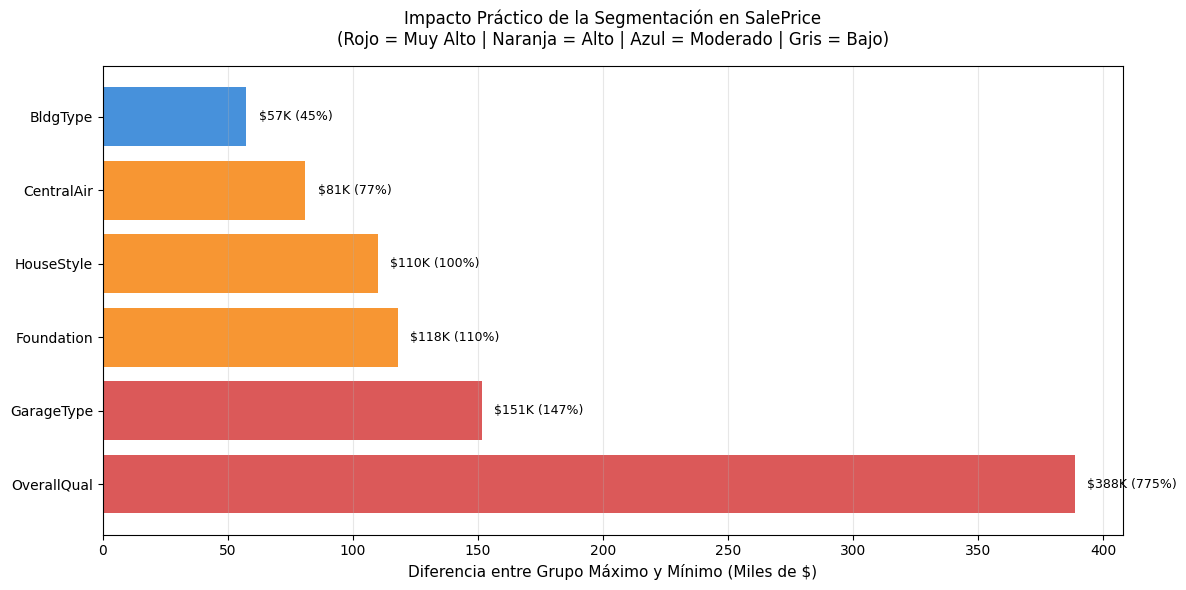

In [0]:
# Crear tabla resumen de todas las variables analizadas
import pandas as pd

df_resumen = pd.DataFrame(resultados)
df_resumen = df_resumen.sort_values('Diferencia_%', ascending=False)

print("\n" + "="*80)
print("RESUMEN: IMPACTO PRÁCTICO DE CADA SEGMENTACIÓN")
print("="*80)
print("\n📄 Ranking por diferencia porcentual (Mayor impacto práctico):\n")

for idx, row in df_resumen.iterrows():
    print(f"{row['Variable']:15s} | Rango: ${row['Diferencia_$']:>9,.0f} ({row['Diferencia_%']:>5.1f}%) | "
          f"Máx: {str(row['Grupo_Max'])[:15]:15s} | Mín: {str(row['Grupo_Min'])[:15]:15s}")

print("\n" + "="*80)
print("💡 DIFERENCIA ESTADÍSTICA vs PRÁCTICA")
print("="*80)

print("""
➡️  SIGNIFICANCIA ESTADÍSTICA (prueba t, p-valor):
   • Responde: "¿La diferencia es REAL o es azar?"
   • Depende del tamaño de muestra
   • Con muchos datos, diferencias PEQUEÑAS pueden ser estadísticamente significativas
   • Ejemplo: p < 0.05 solo significa "no es coincidencia", no "es importante"

➡️  SIGNIFICANCIA PRÁCTICA (diferencia en $, diferencia %):
   • Responde: "¿La diferencia IMPORTA para mi negocio?"
   • No depende del tamaño de muestra
   • Ejemplo: Diferencia de $2,000 (1%) puede ser significativa estadísticamente,
              pero NO justifica una estrategia de negocio diferente.

🎯 REGLA PRÁCTICA PARA ESTE DATASET:
   • Diferencia < 20% ($30K):  BAJA relevancia práctica
   • Diferencia 20-50% ($30K-$80K):  MODERADA — considerar en el modelo
   • Diferencia > 50% ($80K+):  ALTA — segmentación crítica
   • Diferencia > 100% ($160K+): MUY ALTA — casi como datasets diferentes

📊 EN ESTE DATASET:
   • OverallQual (calidad 1 vs 10): $388K de diferencia (775%) → EXTREMA
   • GarageType (BuiltIn vs Sin garaje): $151K de diferencia (147%) → MUY ALTA
   • CentralAir (Sí vs No): $81K de diferencia (77%) → ALTA
   • BldgType (Casa vs 2fmCon): $57K de diferencia (45%) → MODERADA

⚠️  MENSAJE CLAVE:
   NO confundir "estadísticamente significativo" con "prácticamente relevante".
   Una prueba t puede darte p=0.001 (muy significativa estadísticamente) con
   una diferencia de solo $500 — pero ¿eso realmente cambia tu estrategia de pricing?
""")

print("\n📊 VISUALIZACIÓN DE RANGO DE PRECIOS POR VARIABLE:\n")

# Gráfico de barras horizontales mostrando el rango
fig, ax = plt.subplots(figsize=(12, 6))

y_pos = range(len(df_resumen))
rangos = df_resumen['Diferencia_$'].values / 1000  # En miles
labels = df_resumen['Variable'].values

colors = ['#d32f2f' if x > 150 else '#f57c00' if x > 80 else '#1976d2' if x > 30 else '#757575' 
          for x in rangos]

ax.barh(y_pos, rangos, color=colors, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Diferencia entre Grupo Máximo y Mínimo (Miles de $)', fontsize=11)
ax.set_title('Impacto Práctico de la Segmentación en SalePrice\n(Rojo = Muy Alto | Naranja = Alto | Azul = Moderado | Gris = Bajo)', 
             fontsize=12, pad=15)
ax.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (val, pct) in enumerate(zip(rangos, df_resumen['Diferencia_%'].values)):
    ax.text(val + 5, i, f'${val:.0f}K ({pct:.0f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [0]:
# Analizar la dispersión (std) dentro de cada grupo
# Coeficiente de Variación (CV) = (std / mean) * 100
# CV alto = grupo heterogéneo = más difícil de predecir

print("=== ANÁLISIS DE DISPERSIÓN POR GRUPO ===")
print("\nBuscando grupos con alta variabilidad interna (difíciles de predecir)...\n")

# Analizar dispersión para cada variable categórica
resultados_dispersion = []

for col in categoricas_analizar:
    if col not in df_clean.columns:
        continue
        
    stats_grupo = df_clean.groupby(col)['SalePrice'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('std', 'std')
    ])
    
    # Calcular Coeficiente de Variación (CV) = std/mean * 100
    stats_grupo['CV'] = (stats_grupo['std'] / stats_grupo['mean']) * 100
    
    # Ordenar por CV descendente
    stats_grupo = stats_grupo.sort_values('CV', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"VARIABLE: {col}")
    print(f"{'='*70}")
    print(f"\n{'Categoría':20s} {'Mean':>12s} {'Std':>12s} {'CV (%)':>10s} {'n':>6s}")
    print("─" * 70)
    
    for idx, row in stats_grupo.iterrows():
        cv_nivel = "🔴" if row['CV'] > 40 else "🟡" if row['CV'] > 30 else "🟢"
        print(f"{str(idx):20s} ${row['mean']:>10,.0f} ${row['std']:>10,.0f} {row['CV']:>9.1f}% {cv_nivel} {int(row['count']):>5d}")
    
    # Identificar el grupo más heterogéneo
    grupo_max_cv = stats_grupo.index[0]
    cv_max = stats_grupo.loc[grupo_max_cv, 'CV']
    
    print(f"\n  ⚠️  Grupo MÁS HETEROGÉNEO: {grupo_max_cv} (CV = {cv_max:.1f}%)")
    
    if cv_max > 40:
        print(f"  🔴 ALTA variabilidad — grupo muy difícil de predecir")
    elif cv_max > 30:
        print(f"  🟡 MODERADA variabilidad — grupo con dispersión considerable")
    else:
        print(f"  🟢 BAJA variabilidad — grupo relativamente homogéneo")
    
    resultados_dispersion.append({
        'Variable': col,
        'Grupo_Max_CV': grupo_max_cv,
        'CV_Max': cv_max,
        'Mean_Max_CV': stats_grupo.loc[grupo_max_cv, 'mean'],
        'Std_Max_CV': stats_grupo.loc[grupo_max_cv, 'std']
    })

print("\n" + "="*70)
print("📊 Interpretación del Coeficiente de Variación (CV):")
print("="*70)
print("""
  • CV < 30%:  Grupo HOMOGÉNEO — fácil de predecir
  • CV 30-40%: Grupo MODERADAMENTE HETEROGÉNEO
  • CV > 40%:  Grupo MUY HETEROGÉNEO — difícil de predecir

🎯 Por qué importa:
  • Alta dispersión = predicciones menos confiables
  • Un grupo heterogéneo puede necesitar segmentación adicional
  • El modelo tendrá mayor error en grupos con alta std
""")

=== ANÁLISIS DE DISPERSIÓN POR GRUPO ===

Buscando grupos con alta variabilidad interna (difíciles de predecir)...


VARIABLE: OverallQual

Categoría                    Mean          Std     CV (%)      n
──────────────────────────────────────────────────────────────────────
10                   $   438,588 $   159,785      36.4% 🟡    18
1                    $    50,150 $    15,344      30.6% 🟡     2
3                    $    87,474 $    24,689      28.2% 🟢    20
2                    $    51,770 $    14,254      27.5% 🟢     3
4                    $   108,421 $    29,022      26.8% 🟢   116
8                    $   274,736 $    63,899      23.3% 🟢   168
6                    $   161,603 $    36,090      22.3% 🟢   374
9                    $   367,513 $    81,278      22.1% 🟢    43
7                    $   207,716 $    44,466      21.4% 🟢   319
5                    $   133,523 $    27,107      20.3% 🟢   397

  ⚠️  Grupo MÁS HETEROGÉNEO: 10 (CV = 36.4%)
  🟡 MODERADA variabilidad — grupo con 

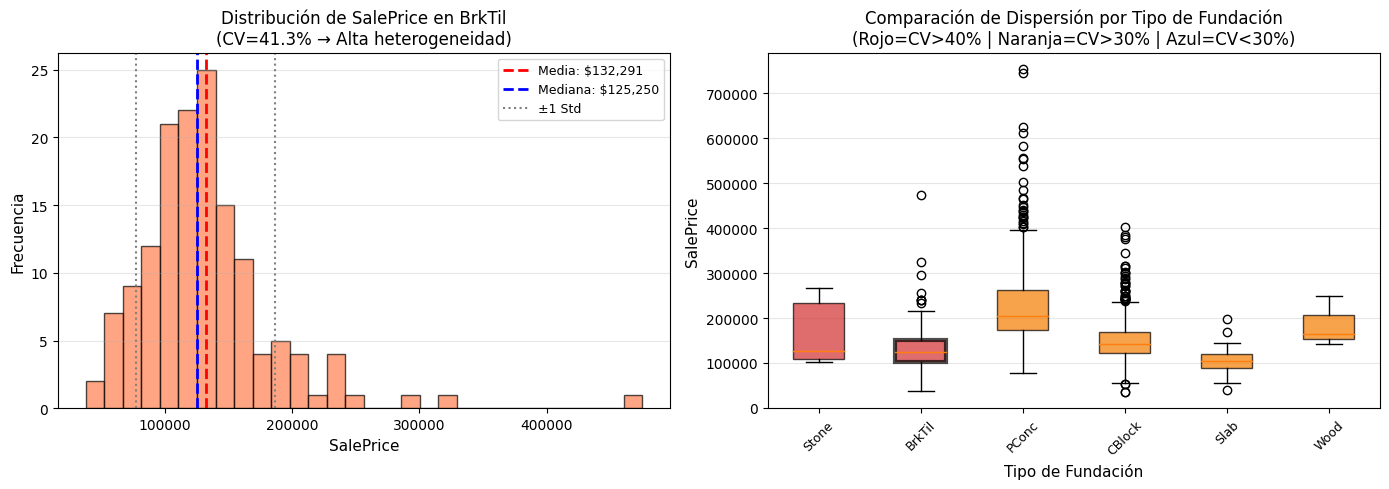


🔍 En el histograma (izquierda):
  • Distribución AMPLIA = alta variabilidad
  • Si fuera un grupo homogéneo, veríamos una campana estrecha
  • Aquí vemos una distribución extendida desde $38K hasta $475K

🔍 En el boxplot (derecho):
  • BrkTil tiene caja ROJA (CV>40%) con borde negro grueso
  • Caja ALTA = mucha dispersión entre Q1 y Q3
  • Muchos outliers superiores = valores extremos que no siguen el patrón

🎯 CONCLUSIÓN:
  • BrkTil es el 2º grupo MÁS HETEROGÉNEO (solo superado por Stone)
  • Con n=146 casas, es una muestra SUFICIENTE (no es problema de muestra pequeña)
  • La heterogeneidad es REAL → necesita variables adicionales para predecir bien


In [0]:
# Calcular estadísticas para BrkTil
bricktile_data = df_clean[df_clean['Foundation'] == 'BrkTil']['SalePrice'].dropna()
mean_bt = bricktile_data.mean()
median_bt = bricktile_data.median()
std_bt = bricktile_data.std()
cv_bt = (std_bt / mean_bt) * 100

# Crear tabla comparativa de todos los tipos de fundación
comparacion = df_clean.groupby('Foundation')['SalePrice'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std')
])
comparacion['CV'] = (comparacion['std'] / comparacion['mean']) * 100
comparacion = comparacion.sort_values('CV', ascending=False)

# Visualización: distribución de precios en BrkTil vs otros tipos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histograma de BrkTil
ax1 = axes[0]
ax1.hist(bricktile_data, bins=30, color='coral', alpha=0.7, edgecolor='black')
ax1.axvline(mean_bt, color='red', linestyle='--', linewidth=2, label=f'Media: ${mean_bt:,.0f}')
ax1.axvline(median_bt, color='blue', linestyle='--', linewidth=2, label=f'Mediana: ${median_bt:,.0f}')
ax1.axvline(mean_bt - std_bt, color='gray', linestyle=':', linewidth=1.5, label='±1 Std')
ax1.axvline(mean_bt + std_bt, color='gray', linestyle=':', linewidth=1.5)
ax1.set_xlabel('SalePrice', fontsize=11)
ax1.set_ylabel('Frecuencia', fontsize=11)
ax1.set_title(f'Distribución de SalePrice en BrkTil\n(CV={cv_bt:.1f}% → Alta heterogeneidad)', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Subplot 2: Boxplot comparativo
ax2 = axes[1]
data_boxplot = [df_clean[df_clean['Foundation'] == f]['SalePrice'].dropna() for f in comparacion.index]
labels_boxplot = comparacion.index.tolist()

bp = ax2.boxplot(data_boxplot, labels=labels_boxplot, patch_artist=True)

# Colorear por CV
for i, foundation in enumerate(comparacion.index):
    cv_val = comparacion.loc[foundation, 'CV']
    if cv_val > 40:
        color = '#d32f2f'  # Rojo
    elif cv_val > 30:
        color = '#f57c00'  # Naranja
    else:
        color = '#1976d2'  # Azul
    
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.7)
    
    # Resaltar BrkTil
    if foundation == 'BrkTil':
        bp['boxes'][i].set_linewidth(3)
        bp['boxes'][i].set_edgecolor('black')

ax2.set_ylabel('SalePrice', fontsize=11)
ax2.set_xlabel('Tipo de Fundación', fontsize=11)
ax2.set_title('Comparación de Dispersión por Tipo de Fundación\n(Rojo=CV>40% | Naranja=CV>30% | Azul=CV<30%)', fontsize=12)
ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 En el histograma (izquierda):")
print("  • Distribución AMPLIA = alta variabilidad")
print("  • Si fuera un grupo homogéneo, veríamos una campana estrecha")
print("  • Aquí vemos una distribución extendida desde $38K hasta $475K")
print("\n🔍 En el boxplot (derecho):")
print("  • BrkTil tiene caja ROJA (CV>40%) con borde negro grueso")
print("  • Caja ALTA = mucha dispersión entre Q1 y Q3")
print("  • Muchos outliers superiores = valores extremos que no siguen el patrón")
print("\n🎯 CONCLUSIÓN:")
print(f"  • BrkTil es el 2º grupo MÁS HETEROGÉNEO (solo superado por Stone)")
print(f"  • Con n=146 casas, es una muestra SUFICIENTE (no es problema de muestra pequeña)")
print(f"  • La heterogeneidad es REAL → necesita variables adicionales para predecir bien")

### BLOQUE F — Prueba de hipótesis sobre sus datos
Elijan dos grupos de su dataset y prueben si la diferencia en la variable objetivo es estadísticamente significativa.

In [0]:
# Ejemplo: ¿el grupo A tiene un valor promedio diferente al grupo B?

GRUPO_A = "PConc"   # ejemplo válido
GRUPO_B = "CBlock"   # ejemplo válido

datos_A = mi_df[mi_df[COLUMNA_SEGMENTO] == GRUPO_A][COLUMNA_OBJETIVO].dropna()
datos_B = mi_df[mi_df[COLUMNA_SEGMENTO] == GRUPO_B][COLUMNA_OBJETIVO].dropna()

t_stat, p_val = stats.ttest_ind(datos_A, datos_B)

sesgo = mi_df['SalePrice'].skew()

print(f"Prueba t — {GRUPO_A} vs {GRUPO_B}")
print(f"  Media {GRUPO_A}: {datos_A.mean():.2f}")
print(f"  Media {GRUPO_B}: {datos_B.mean():.2f}")
print(f"  Diferencia:      {datos_A.mean() - datos_B.mean():.2f}")
print(f"  Valor p:         {p_val:.4f}")
print(f"Sesgo (Skewness):  {sesgo:.4f} (Valores > 1 indican alto sesgo a la derecha)")
print()
if p_val < 0.05:
    print("  → Diferencia estadísticamente significativa (p < 0.05).")
    print("  → Ahora la pregunta importante: ¿es relevante para su negocio?")
else:
    print("  → No hay evidencia suficiente de diferencia real.")
    print("  → Eso también es información: los grupos se comportan igual.")


Prueba t — PConc vs CBlock
  Media PConc: 225230.44
  Media CBlock: 149805.71
  Diferencia:      75424.73
  Valor p:         0.0000
Sesgo (Skewness):  1.8829 (Valores > 1 indican alto sesgo a la derecha)

  → Diferencia estadísticamente significativa (p < 0.05).
  → Ahora la pregunta importante: ¿es relevante para su negocio?


### FIN